# 🔴 Project - German Credit: SVM with Business Costs (End-to-End)

> **MLCourse · Machine Learning · supervised · classification**

### Business question
Approve/reject 1,000 real credit applications (OpenML credit-g). Errors cost
different dollars - we grid-search SVMs, then price the confusion matrix like
a lender and MOVE the operating point until dollars stop improving.

End-to-end: fetch+cache CSV → EDA → processing (mixed types) → training →
dollar evaluation.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             precision_score, recall_score)

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

ML_ROOT = Path.cwd()
while ML_ROOT.name != "02_machine_learning" and ML_ROOT != ML_ROOT.parent:
    ML_ROOT = ML_ROOT.parent
DATA = ML_ROOT / "data"; DATA.mkdir(exist_ok=True)

### 2. Data loading - fetch once, cache as CSV


In [2]:
csv_path = DATA / "german_credit.csv"
if csv_path.exists():
    print("using local -> german_credit.csv")
    df = pd.read_csv(csv_path)
else:
    try:
        df = fetch_openml(name="credit-g", version=1, as_frame=True,
                          parser="auto").frame
        df.to_csv(csv_path, index=False)
        print("downloaded -> german_credit.csv")
    except Exception as e:
        print("OpenML unreachable:", e); raise

df["class"] = (df["class"] == "bad").astype(int)   # 1 = DEFAULTER
y_full = df.pop("class")
print(df.shape, "| default rate:", round(df["class"].mean() if False else y_full.mean(), 3))
display(df.head(3))

using local -> german_credit.csv
(1000, 20) | default rate: 0.3


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,4,real estate,67,none,own,2,skilled,1,yes,yes
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,2,real estate,22,none,own,1,skilled,1,none,yes
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,3,real estate,49,none,own,1,unskilled resident,2,none,yes


### 3. Exploratory Data Analysis


7 numeric | 13 categorical


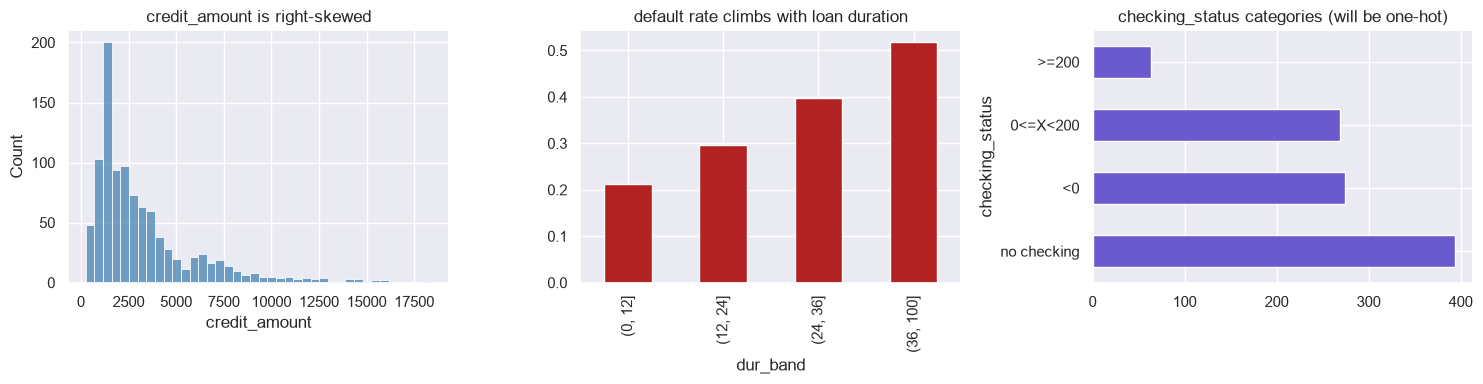


NaNs: 0


In [3]:
num_cols = df.select_dtypes(include="number").columns.tolist()
cat_cols = df.select_dtypes(exclude="number").columns.tolist()
print(f"{len(num_cols)} numeric | {len(cat_cols)} categorical")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df.credit_amount, bins=40, ax=axes[0], color="steelblue")
axes[0].set_title("credit_amount is right-skewed")

bad_rate_by_dur = df.assign(dur_band=pd.cut(df.duration, [0, 12, 24, 36, 100])) \
                    .assign(is_bad=y_full.values) \
                    .groupby("dur_band", observed=True)["is_bad"].mean()
bad_rate_by_dur.plot(kind="bar", color="firebrick", ax=axes[1])
axes[1].set_title("default rate climbs with loan duration")

df.checking_status.value_counts().plot(kind="barh", ax=axes[2], color="slateblue")
axes[2].set_title("checking_status categories (will be one-hot)")
plt.tight_layout(); plt.show()

print("\nNaNs:", int(df.isna().sum().sum()))

### 4. Data processing - mixed types inside ColumnTransformer


In [4]:
y = y_full.values
X_tr, X_te, y_tr, y_te = train_test_split(df, y, test_size=.25,
                                          random_state=42, stratify=y)

pre = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

### 5. Model training


In [5]:
grid = GridSearchCV(
    Pipeline([("pre", pre), ("svm", SVC())]),
    {"svm__kernel": ["rbf"], "svm__C": [1, 10, 50],
     "svm__gamma": ["scale", 0.01]},
    cv=5, scoring="f1", n_jobs=-1)
grid.fit(X_tr, y_tr)
pred = grid.predict(X_te)

print("best:", grid.best_params_, f"| CV F1 {grid.best_score_:.3f}")
print(f"test acc {accuracy_score(y_te, pred):.3f} "
      f"| default-recall {recall_score(y_te, pred):.3f} "
      f"| default-precision {precision_score(y_te, pred):.3f}")
display(pd.DataFrame(confusion_matrix(y_te, pred),
                     index=["true good", "true bad"],
                     columns=["pred good", "pred bad"]))

best: {'svm__C': 50, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'} | CV F1 0.518
test acc 0.760 | default-recall 0.573 | default-precision 0.606


,pred good,pred bad
true good,147,28
true bad,32,43


### 5b. Dollar ledger - approve-defaulter \$1500, reject-good \$500


,margin_threshold,total_cost_$,defaults_missed,good_rejected
0,-1.0,58000,12,80
1,-0.5,60000,23,51
2,0.0,62000,32,28
3,0.5,73000,44,14


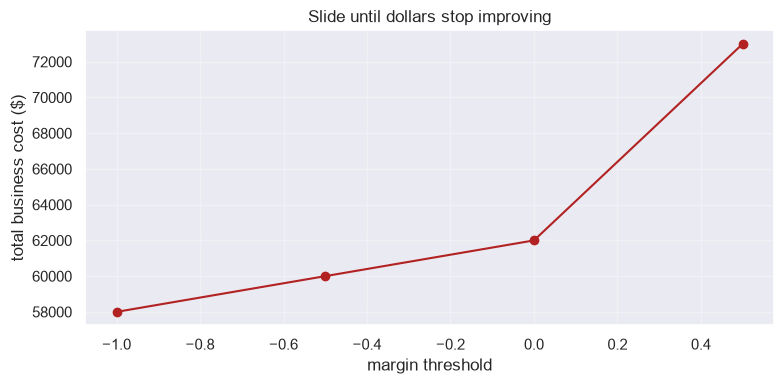

In [6]:
cost_matrix = {(1, 0): 1500, (0, 1): 500}

dec = grid.best_estimator_.decision_function(X_te)
rows = []
for t in [-1.0, -0.5, 0.0, 0.5]:
    lab = (dec >= t).astype(int)
    total = sum(cost_matrix.get((yt, yp), 0) for yt, yp in zip(y_te, lab))
    cm_t = confusion_matrix(y_te, lab)
    rows.append({"margin_threshold": t,
                 "total_cost_$": int(total),
                 "defaults_missed": int(cm_t[1, 0]),
                 "good_rejected": int(cm_t[0, 1])})
ledger = pd.DataFrame(rows)
display(ledger)

plt.figure(figsize=(8, 4))
plt.plot(ledger.margin_threshold, ledger["total_cost_$"], "o-", color="firebrick")
plt.xlabel("margin threshold"); plt.ylabel("total business cost ($)")
plt.grid(alpha=.3); plt.title("Slide until dollars stop improving")
plt.tight_layout(); plt.show()

### 6. Findings & recommendation

1. Accuracy ~74-77% misleads; the LEDGER says flag risk earlier (threshold < 0).
2. Duration & amount drive default risk - consistent with EDA bars.
3. One-hot inflation (~60 cols) is fine for RBF here, but tree ensembles often
     win this game (later modules).

### Takeaway
Optimize the currency your business pays in, not the accuracy percentage.